In [1]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS

from tqdm import tqdm

In [3]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S1_00.s3m', 'S3Mdata/S1_01.s3m', 'S3Mdata/S1_02.s3m', 'S3Mdata/S1_03.s3m', 'S3Mdata/S1_04.s3m', 'S3Mdata/S1_05.s3m', 'S3Mdata/S1_06.s3m', 'S3Mdata/S1_07.s3m', 'S3Mdata/S1_08.s3m', 'S3Mdata/S1_09.s3m', 'S3Mdata/S1_10.s3m', 'S3Mdata/S1_11.s3m', 'S3Mdata/S1_12.s3m', 'S3Mdata/S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [4]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [5]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [6]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [7]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


In [8]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2


In [9]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [10]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [11]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [12]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [13]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [14]:
k_map = 10
n_d0_grid_map = 400

In [15]:
# Population dataframes for cloning / per-population workflows
s3m_mba = s3m
s3m_neo = neo
s3m_tno = tno
s3m_tjn = trojan  

In [16]:

# Clone a population by randomizing mean anomaly at obstime

import gc
import numpy as np
from scipy.spatial import cKDTree
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times by assigning a random mean anomaly
    at obstime_str. Keeps a,e,i,node,argperi fixed and changes only orbital phase
    via t_p.

    Returns repeated orbital element arrays.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    a_AU   = df["a"].to_numpy(dtype=np.float32)
    e      = df["e"].to_numpy(dtype=np.float32)
    inc    = df["i"].to_numpy(dtype=np.float32)
    raan   = df["node"].to_numpy(dtype=np.float32)
    argp   = df["argperi"].to_numpy(dtype=np.float32)

    # repeat fixed elements
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0

    # random mean anomaly at observation epoch
    M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep)).astype(np.float64)

    # choose perihelion time so that M(obstime)=M_rand
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)

    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [17]:
# Convert orbital elements -> vlam, vbeta using your existing pipeline
# but with a configurable sky center in ecliptic lon/lat

def elements_to_vlam_vbeta(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import (
        SkyCoord, GCRS, get_sun, GeocentricTrueEcliptic
    )

    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and RA/Dec rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of the sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg

    m = sep <= max_sep_deg
    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta)
    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)

    return vlam, vbeta

In [18]:

# Clone configuration (less memory intensive)

clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,   # first test: no MBA cloning yet
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

rng = np.random.default_rng(42)
overlay_max = 100_000

In [19]:
# Build cloned rate-space populations one at a time
# Keeps only small overlay samples + final maps

clone_overlay = {}
clone_density_maps = {}
clone_density_maps_downweighted = {}

for pop_name, info in clone_sources.items():
    f = info["clone_factor"]
    df = info["df"]

    print(f"\nCloning {pop_name} with factor {f}...")

    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df, clone_factor=f, obstime_str=obstime_str, rng=rng
    )
    print("  cloned orbit count:", len(a_rep))

    vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
        obstime_str=obstime_str,
        scorer=info["scorer"],
        max_sep_deg=max_sep_deg,
        chunk=100_000,
        show_progress=True,
    )
    print(f"  final cloned visible points: {len(vlam_clone)}")

    # raw element arrays no longer needed
    del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
    gc.collect()

    # keep only a small random subset for plotting overlays
    n_overlay = min(overlay_max, len(vlam_clone))
    idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
    clone_overlay[pop_name] = {
        "vlam": vlam_clone[idx_overlay].copy(),
        "vbeta": vbeta_clone[idx_overlay].copy(),
        "scatter_size": info["scatter_size"],
        "scatter_alpha": info["scatter_alpha"],
    }

    pts_clone = np.column_stack([vlam_clone, vbeta_clone])
    tree_clone = cKDTree(pts_clone)

    density_clone_flat = evaluate_density_map_full_posterior_2d(
        tree_clone,
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_clone_map = density_clone_flat.reshape(X0.shape)
    density_downweighted_map = density_clone_map / f

    clone_density_maps[pop_name] = density_clone_map
    clone_density_maps_downweighted[pop_name] = density_downweighted_map

    print(f"{pop_name} done.")
    print("  raw cloned max density   :", np.nanmax(density_clone_map))
    print("  downweighted max density :", np.nanmax(density_downweighted_map))

    # cleanup large arrays before next population
    del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
    gc.collect()


Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 38.50it/s]


  final cloned visible points: 1418518


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:09<00:00, 200.52it/s]


MBA done.
  raw cloned max density   : 393660850.11085683
  downweighted max density : 393660850.11085683

Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 4990380832.635155
  downweighted max density : 499038083.2635155

Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 40.74it/s]


  final cloned visible points: 221533


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:06<00:00, 204.36it/s]


Trojans done.
  raw cloned max density   : 228962244.82945496
  downweighted max density : 22896224.482945494


In [20]:
def build_cloned_maps_for_center(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] Cloning {pop_name} with factor {f}...")

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            df, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print(f"  final cloned visible points: {len(vlam_clone)}")

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)

        clone_overlay[pop_name] = {
            "vlam": vlam_clone[idx_overlay].copy(),
            "vbeta": vbeta_clone[idx_overlay].copy(),
            "scatter_size": info["scatter_size"],
            "scatter_alpha": info["scatter_alpha"],
        }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        tree_clone = cKDTree(pts_clone)

        density_clone_flat = evaluate_density_map_full_posterior_2d(
            tree_clone,
            grid_points,
            k=k_map,
            n_d0_grid=n_d0_grid_map,
            show_progress=True,
        )

        density_clone_map = density_clone_flat.reshape(X0.shape)
        density_downweighted_map = density_clone_map / f

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

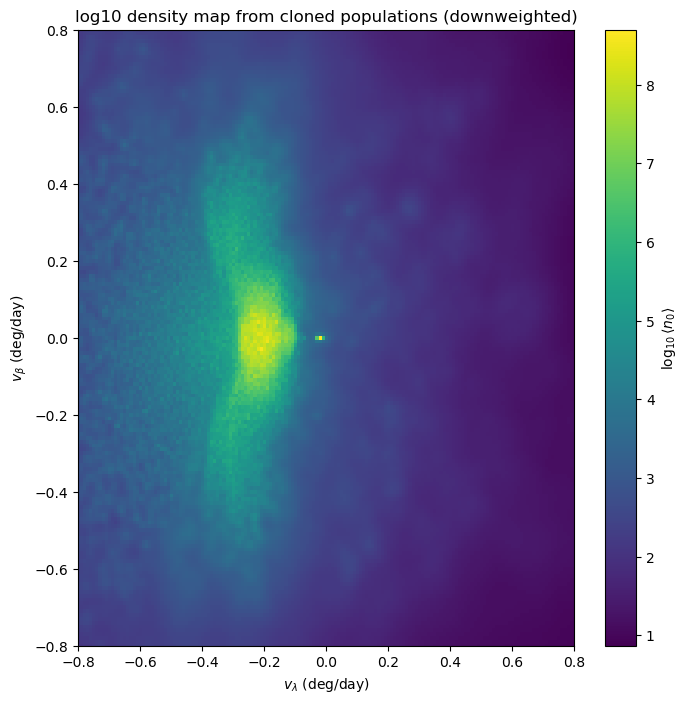

In [21]:

# Combined ALL map from downweighted cloned populations

density_all_clone_downweighted = (
    clone_density_maps_downweighted["MBA"] +
    clone_density_maps_downweighted["NEO"] +
    clone_density_maps_downweighted["TNO"] +
    clone_density_maps_downweighted["Trojans"]
)

log_density_all_clone_downweighted = np.log10(
    np.maximum(density_all_clone_downweighted, 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("log10 density map from cloned populations (downweighted)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

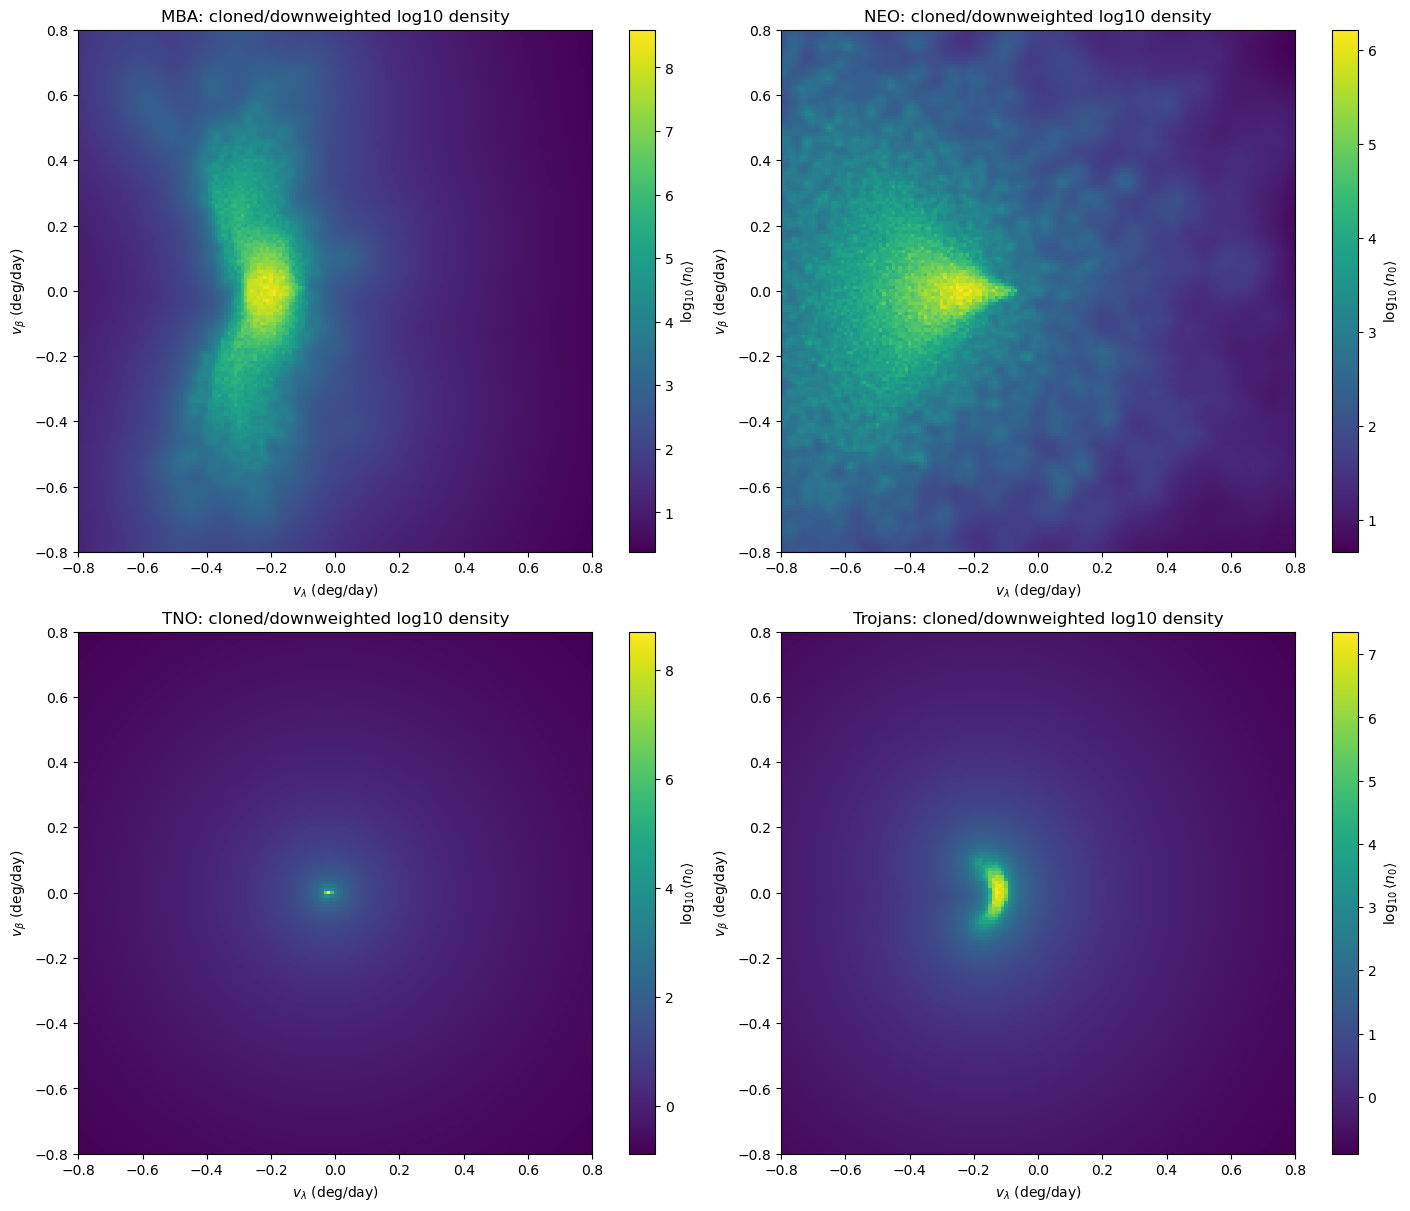

In [22]:

# Plot all 4 cloned/downweighted log-density maps

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

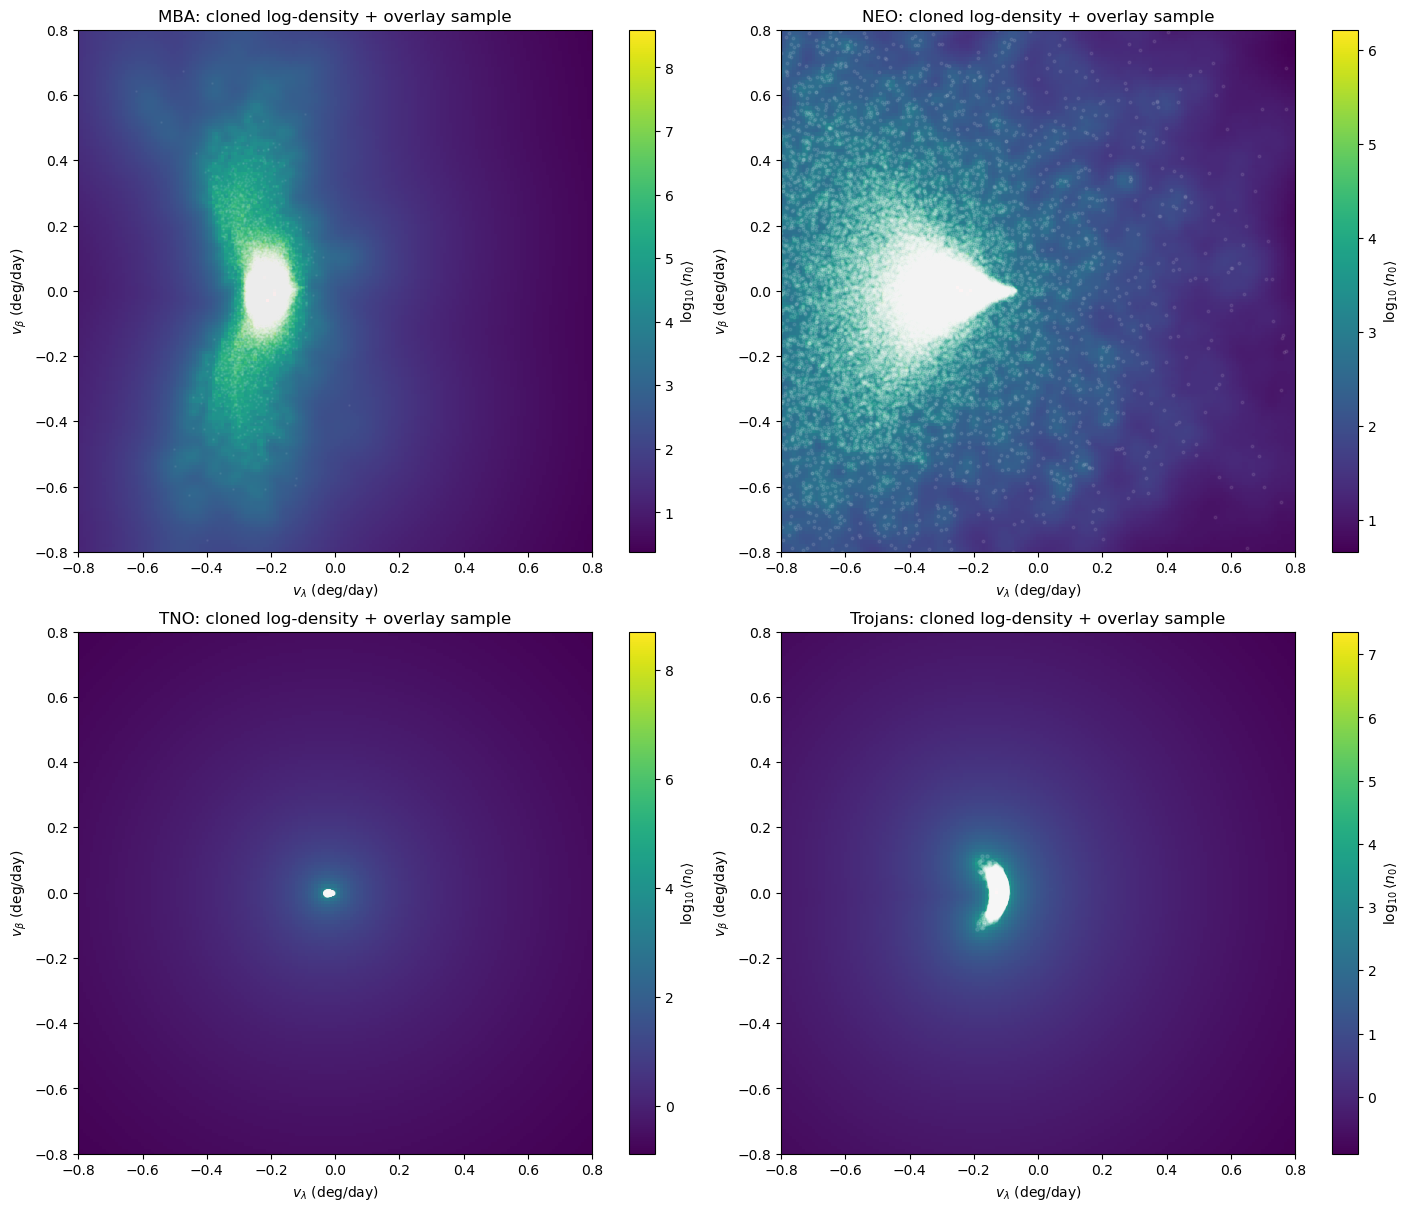

In [23]:

# Plot all 4 cloned/downweighted maps with overlay samples

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))
    overlay = clone_overlay[pop_name]

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned log-density + overlay sample")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [24]:
rng = np.random.default_rng(42)

result_lon180_lat10 = build_cloned_maps_for_center(
    center_lon_deg=180.0,
    center_lat_deg=10.0,
    center_label="lon180_lat10",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=rng,
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)

result_lon180_lat30 = build_cloned_maps_for_center(
    center_lon_deg=180.0,
    center_lat_deg=30.0,
    center_label="lon180_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=rng,
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon180_lat10] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 38.92it/s]


  final cloned visible points: 1334072


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:09<00:00, 200.34it/s]


MBA done.
  raw cloned max density   : 306570568.6603924
  downweighted max density : 306570568.6603924

[lon180_lat10] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 2175203586.5758667
  downweighted max density : 217520358.65758666

[lon180_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 40.82it/s]


  final cloned visible points: 96072


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:08<00:00, 201.53it/s]


Trojans done.
  raw cloned max density   : 127583678.98734088
  downweighted max density : 12758367.898734089


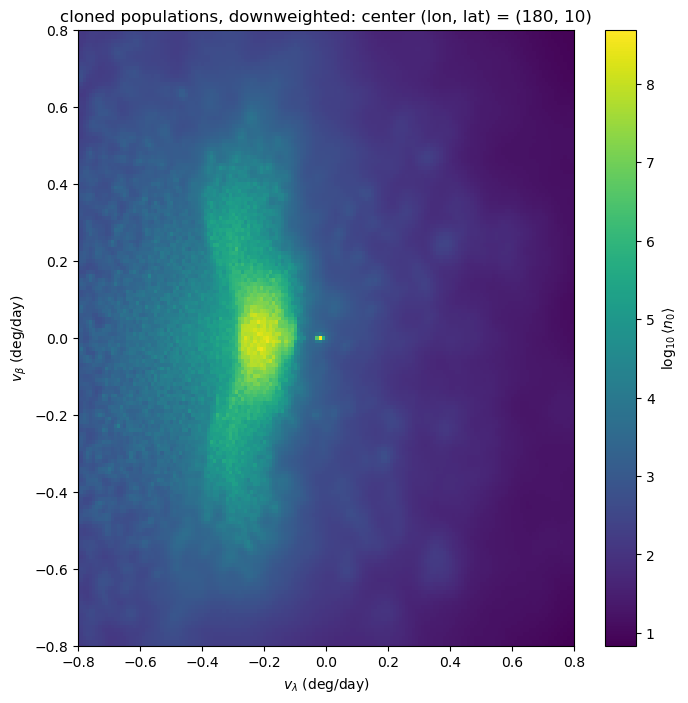

In [25]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon180_lat10["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (180, 10)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

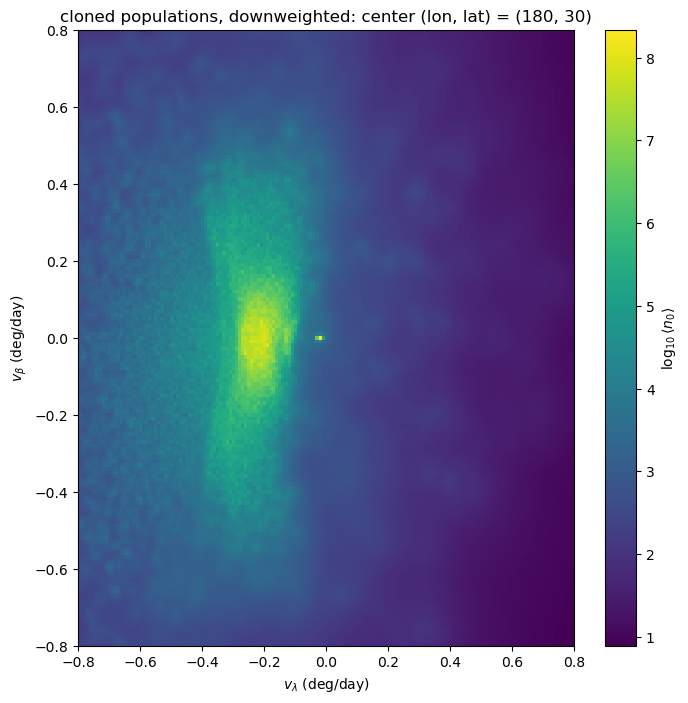

In [26]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon180_lat30["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (180, 30)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

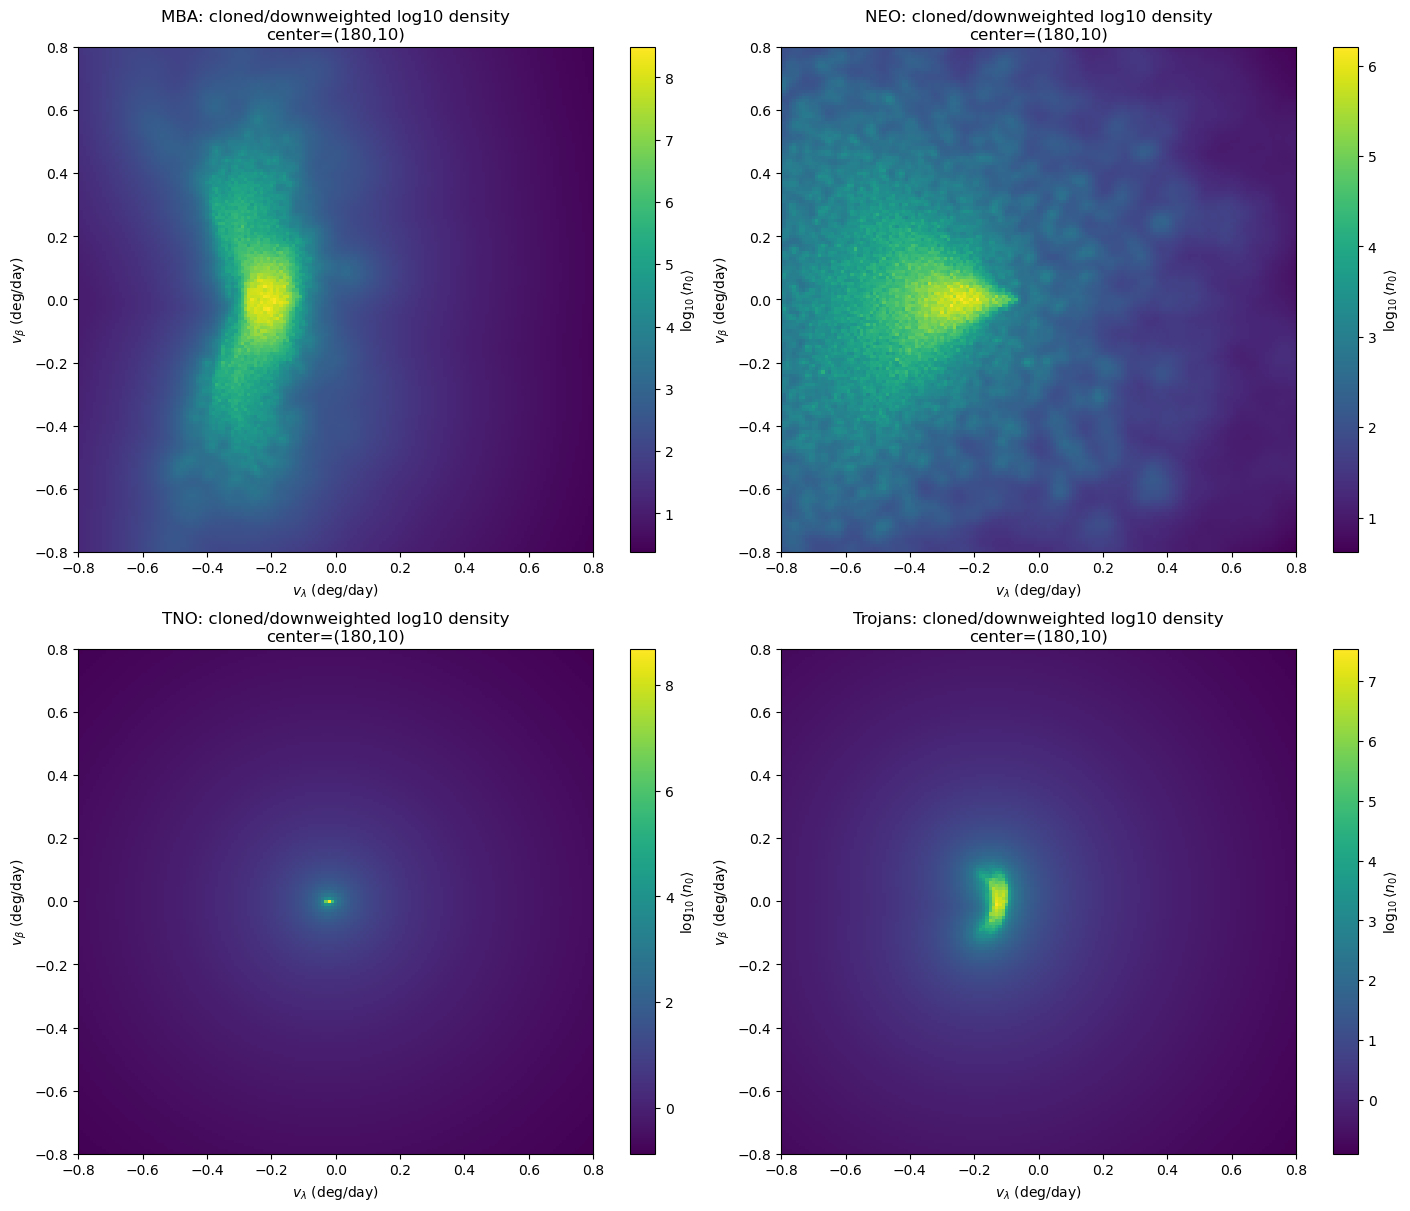

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon180_lat10["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(180,10)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

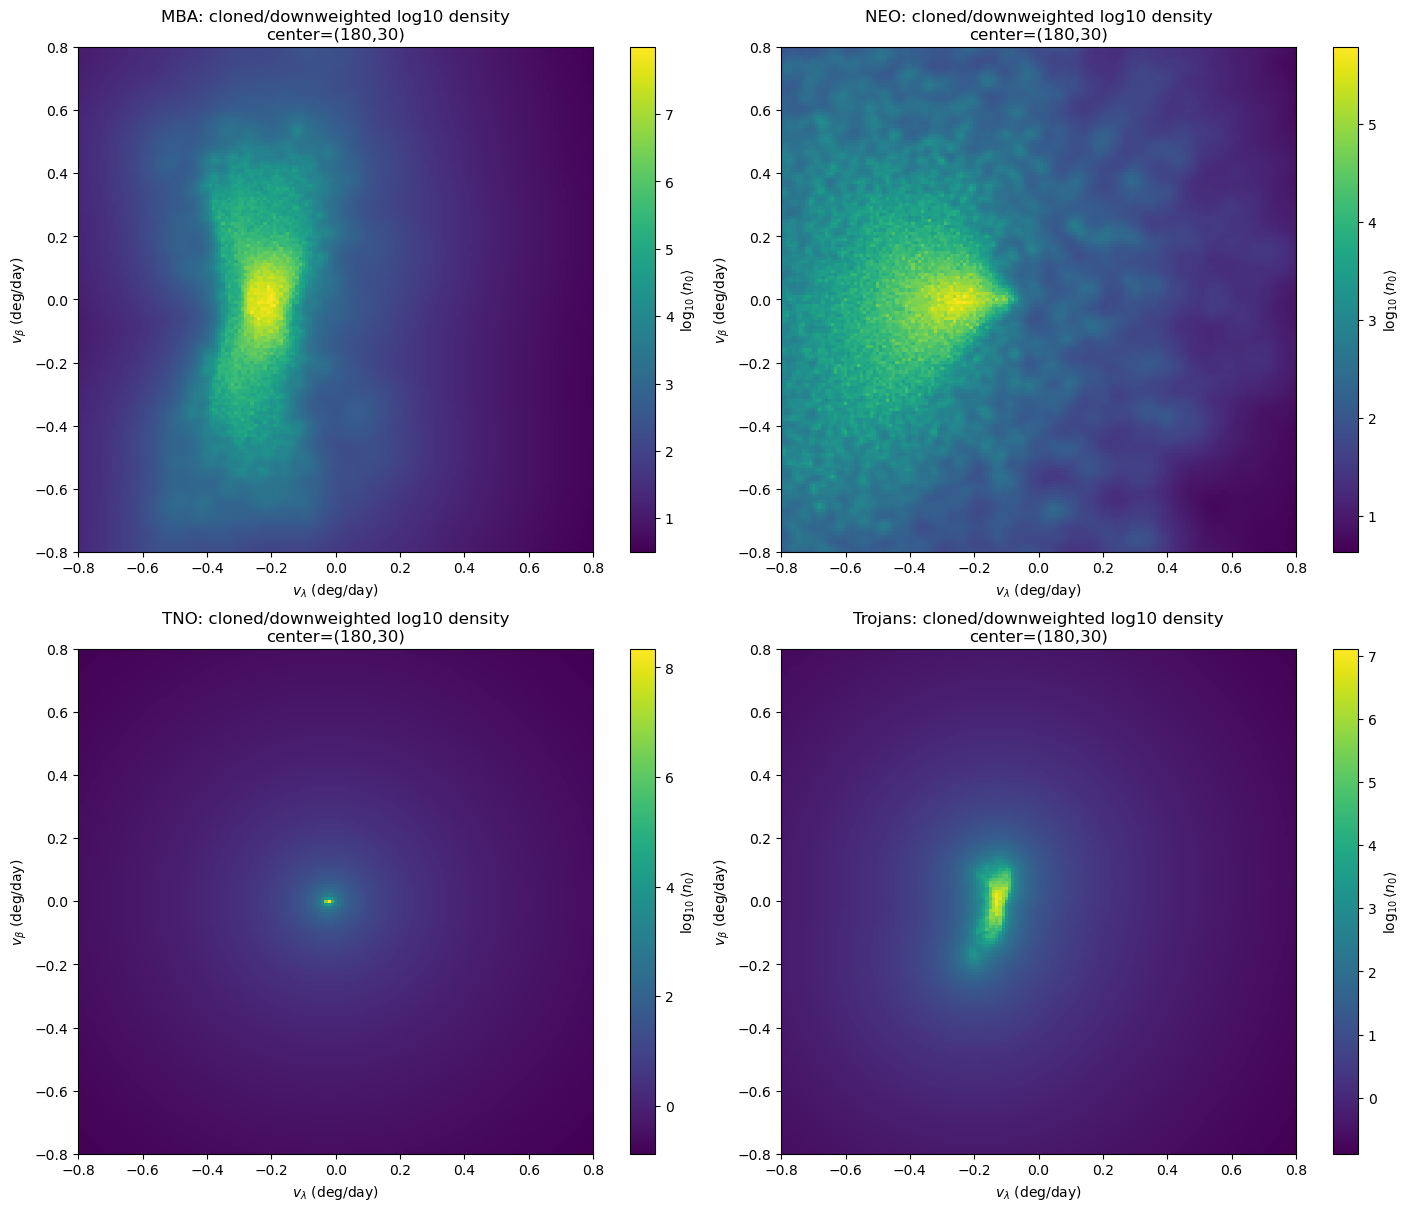

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon180_lat30["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(180,30)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [29]:
result_lon150_lat0 = build_cloned_maps_for_center(
    center_lon_deg=150.0,
    center_lat_deg=0.0,
    center_label="lon150_lat0",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)




[lon150_lat0] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 37.27it/s]


  final cloned visible points: 1524070


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:11<00:00, 197.22it/s]


MBA done.
  raw cloned max density   : 147520164.5293292
  downweighted max density : 147520164.5293292

[lon150_lat0] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 3701872663.3610525
  downweighted max density : 370187266.3361052

[lon150_lat0] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 40.56it/s]


  final cloned visible points: 226407


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:10<00:00, 199.08it/s]


Trojans done.
  raw cloned max density   : 249133953.85843694
  downweighted max density : 24913395.385843694


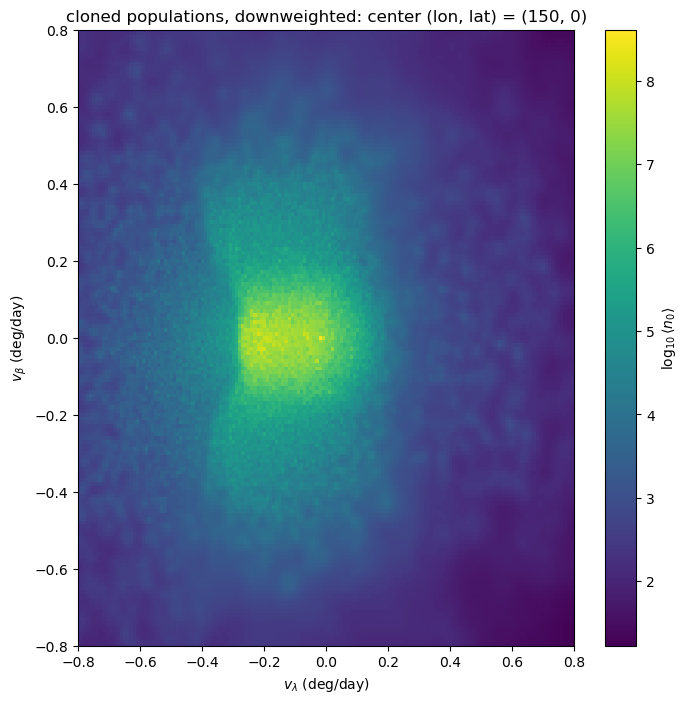

In [30]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon150_lat0["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (150, 0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

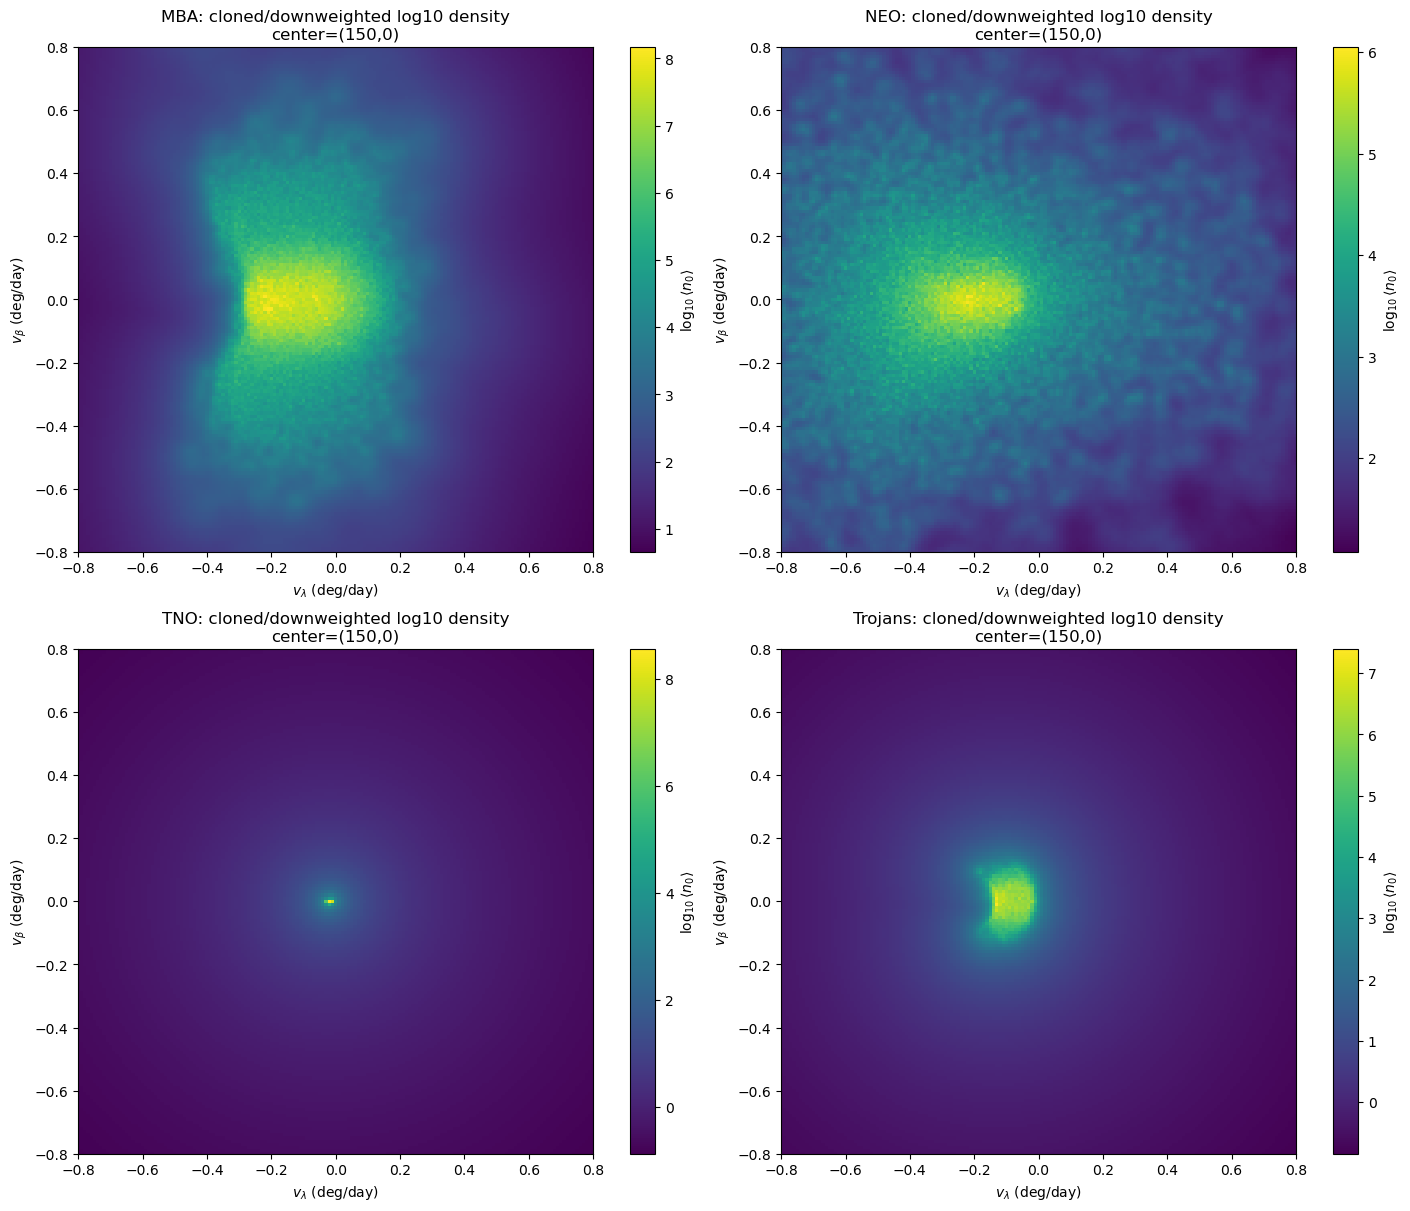

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon150_lat0["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(150,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [32]:
result_lon120_lat0 = build_cloned_maps_for_center(
    center_lon_deg=120.0,
    center_lat_deg=0.0,
    center_label="lon120_lat0",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon120_lat0] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 38.83it/s]


  final cloned visible points: 1812578


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:05<00:00, 206.24it/s]


MBA done.
  raw cloned max density   : 112812023.2124402
  downweighted max density : 112812023.2124402

[lon120_lat0] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 837104288.8040135
  downweighted max density : 83710428.88040134

[lon120_lat0] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 43.63it/s]


  final cloned visible points: 244681


Evaluating density map: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:03<00:00, 210.10it/s]

Trojans done.
  raw cloned max density   : 33959743.479746416
  downweighted max density : 3395974.3479746417


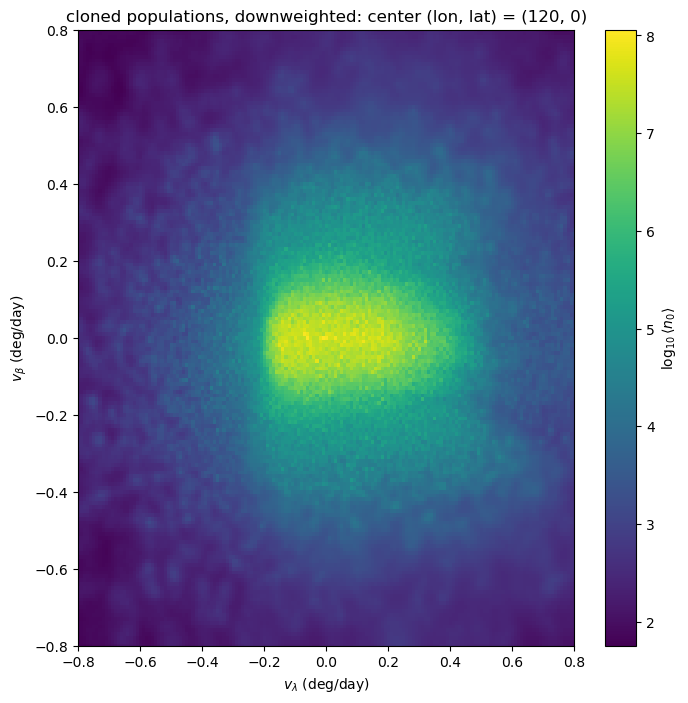

In [33]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon120_lat0["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (120, 0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

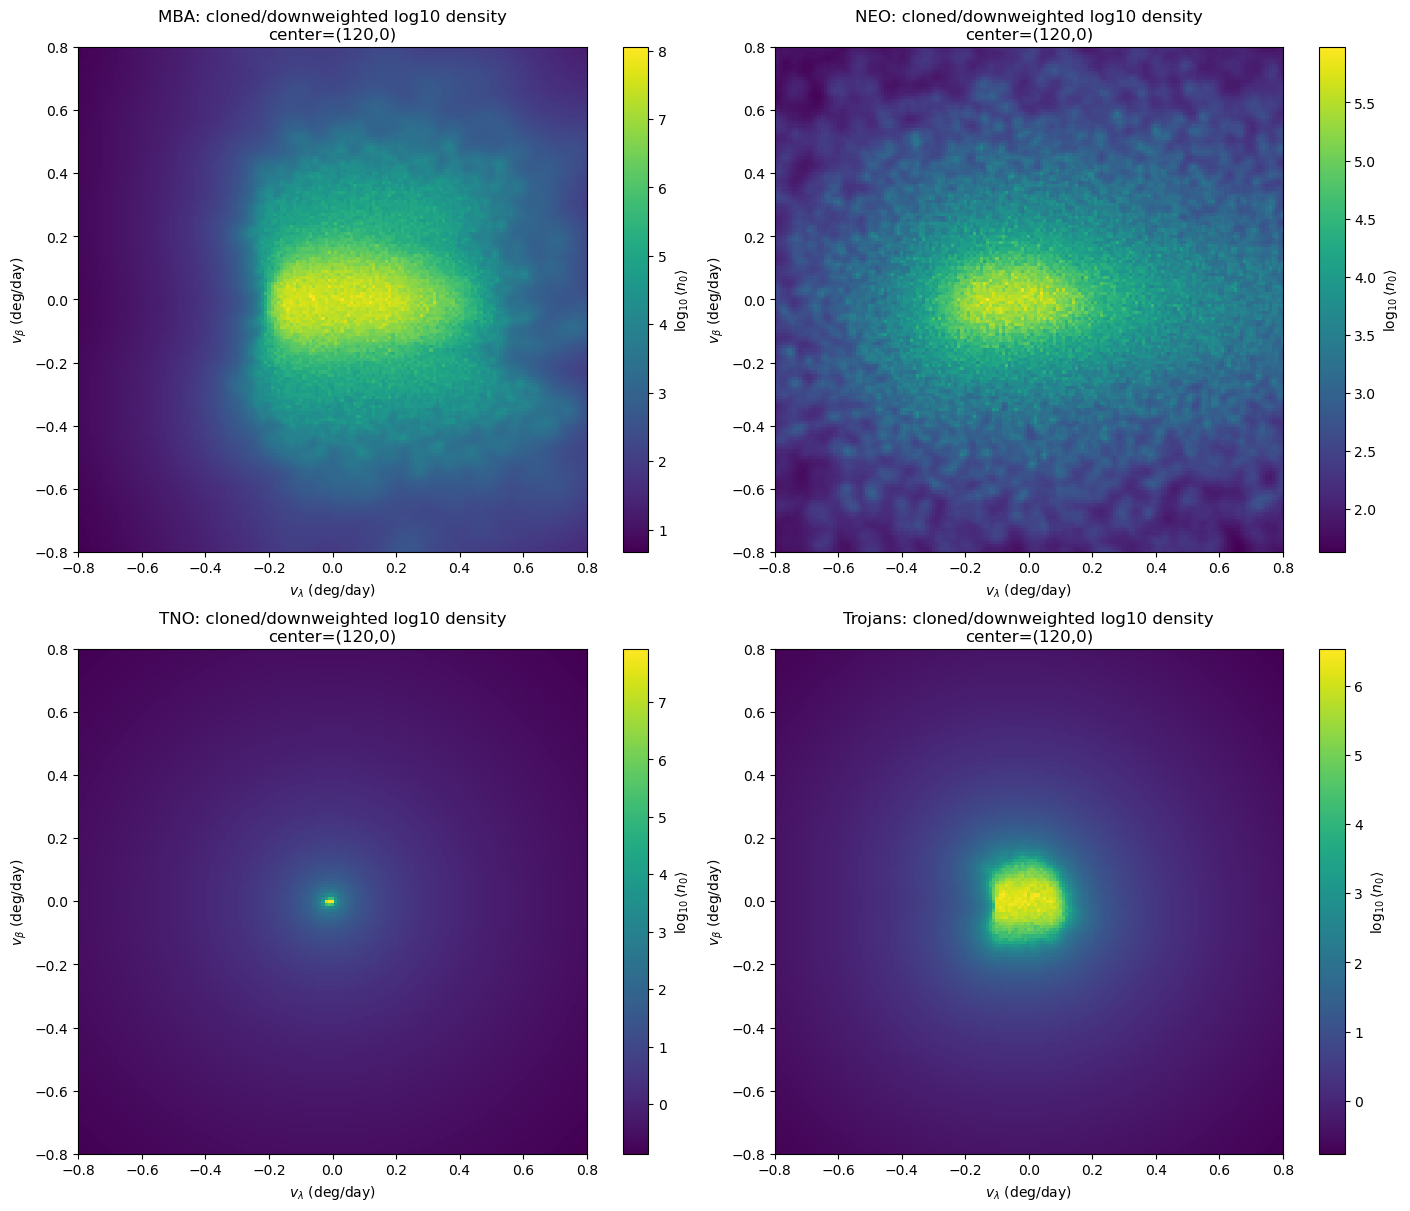

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon120_lat0["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(120,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [38]:
maps = result_lon120_lat0["density_maps_downweighted"]
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

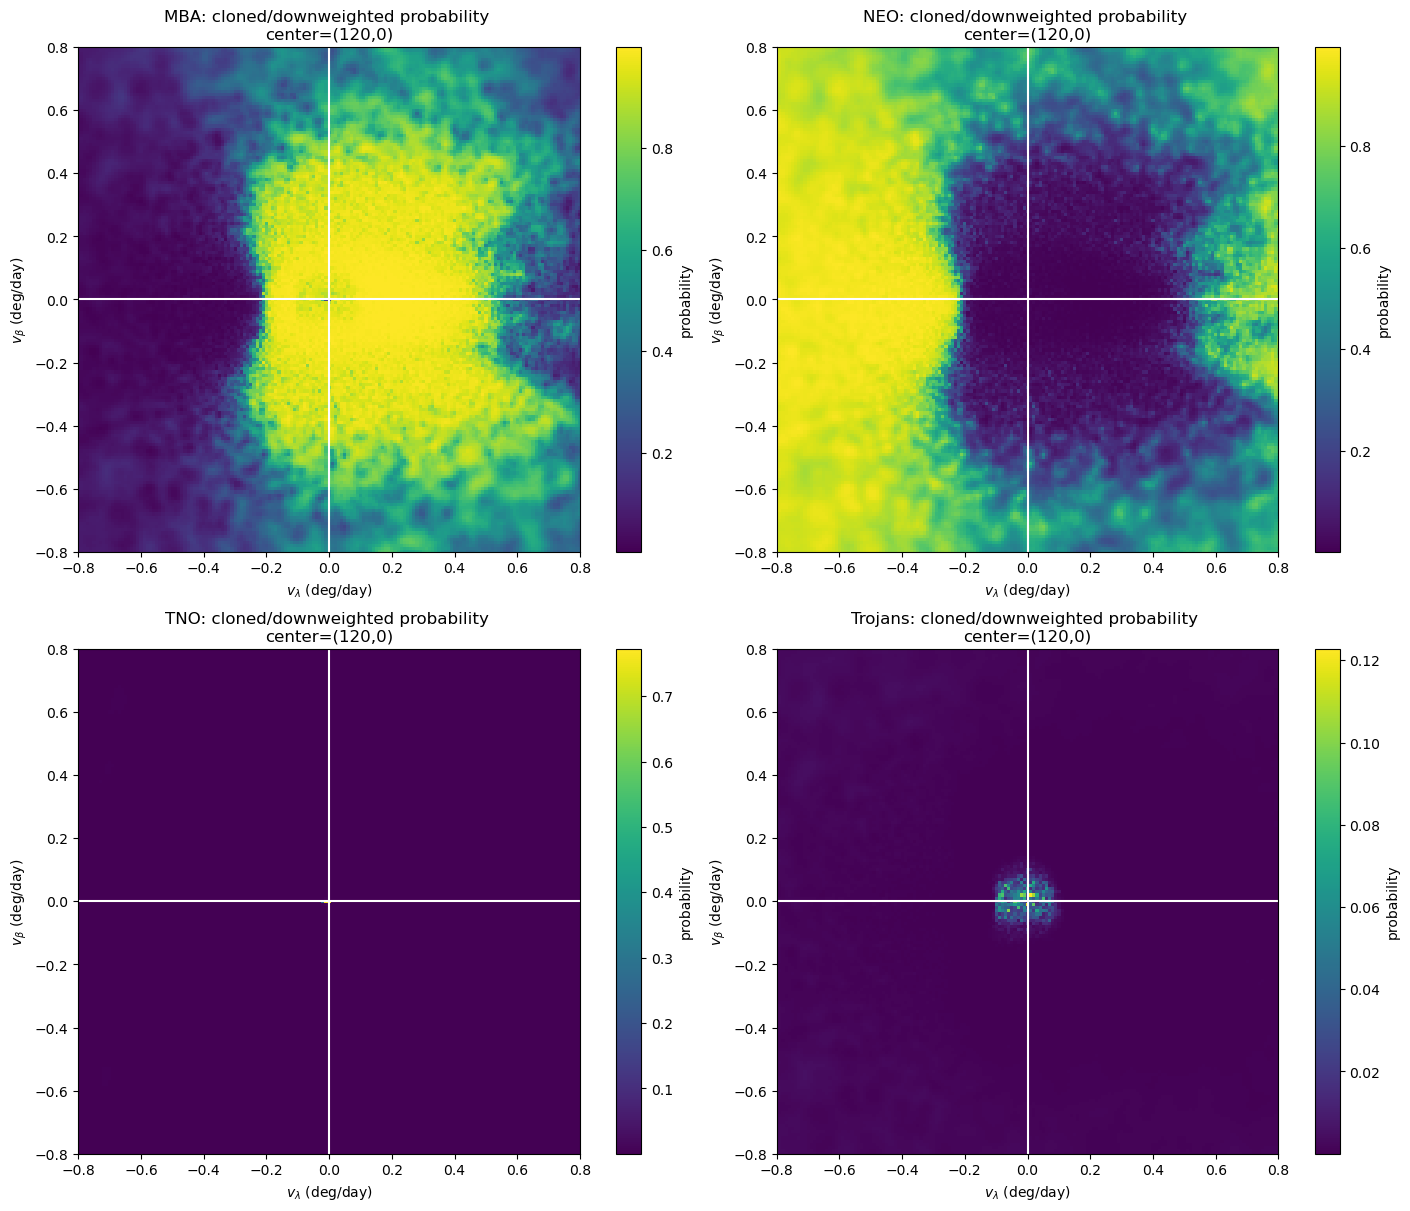

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(120,0)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [44]:
maps = clone_density_maps_downweighted
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

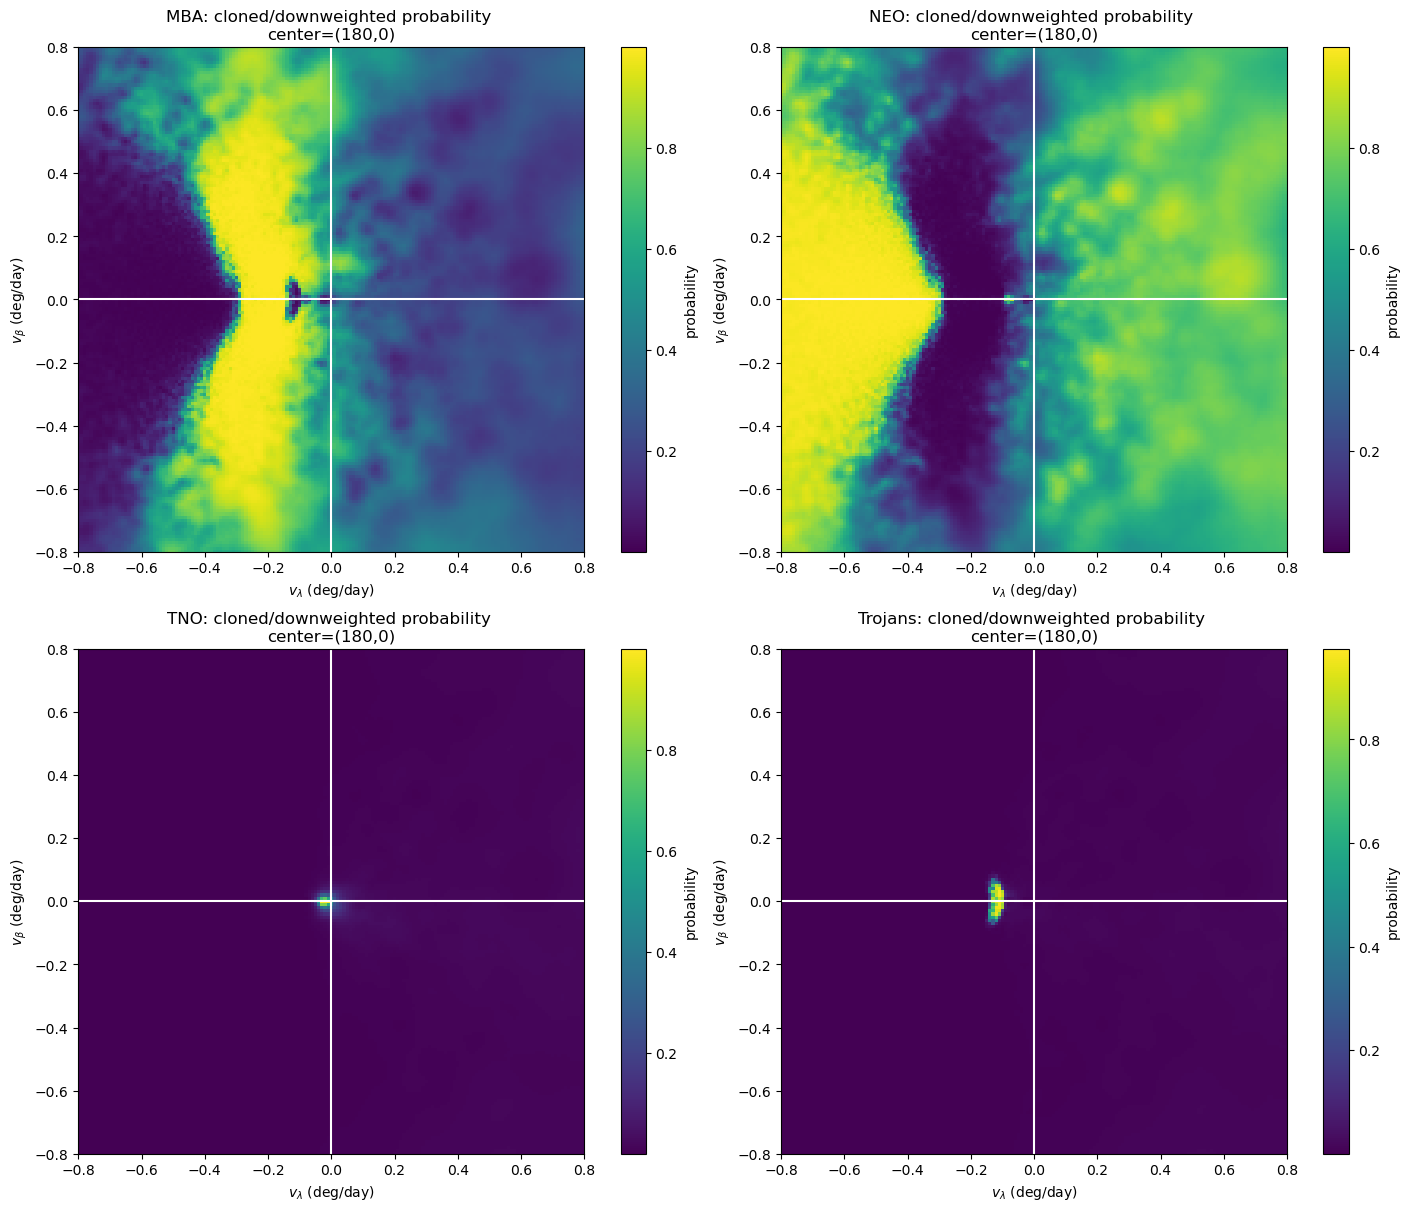

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(180,0)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [48]:
result_lon90_lat30 = build_cloned_maps_for_center(
    center_lon_deg=90.0,
    center_lat_deg=30.0,
    center_label="lon90_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon90_lat30] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 38.33it/s]


  final cloned visible points: 748084


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:04<00:00, 207.71it/s]


MBA done.
  raw cloned max density   : 82984238.14474764
  downweighted max density : 82984238.14474764

[lon90_lat30] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 48976923.63222574
  downweighted max density : 4897692.363222574

[lon90_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 37.45it/s]


  final cloned visible points: 90324


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:06<00:00, 205.26it/s]

Trojans done.
  raw cloned max density   : 24019468.574020594
  downweighted max density : 2401946.8574020592


In [49]:
maps = result_lon90_lat30["density_maps_downweighted"]
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

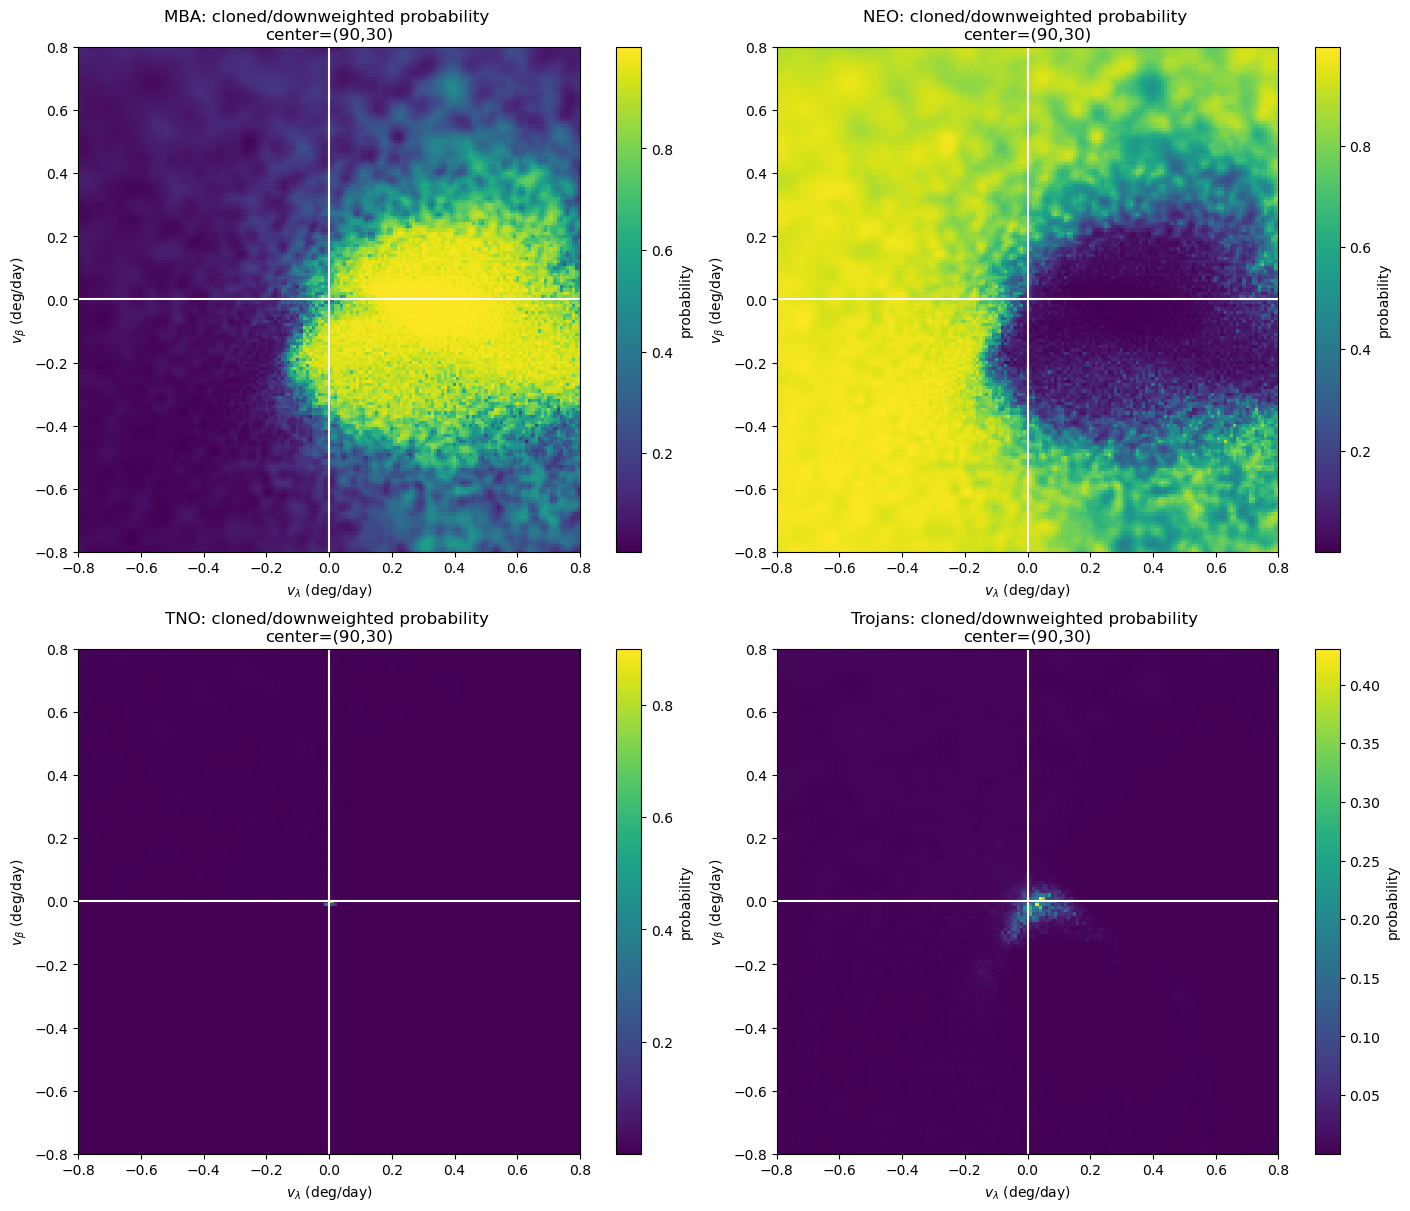

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(90,30)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [51]:
result_lon60_lat00 = build_cloned_maps_for_center(
    center_lon_deg=60.0,
    center_lat_deg=0.0,
    center_label="lon60_lat00",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon60_lat00] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 38.39it/s]


  final cloned visible points: 2597287


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:06<00:00, 204.63it/s]


MBA done.
  raw cloned max density   : 282245450.4890704
  downweighted max density : 282245450.4890704

[lon60_lat00] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 1147272308.5705657
  downweighted max density : 114727230.85705657

[lon60_lat00] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 43.41it/s]


  final cloned visible points: 293649


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:04<00:00, 207.43it/s]


Trojans done.
  raw cloned max density   : 61601919.704321556
  downweighted max density : 6160191.970432156


In [52]:
result_lon60_lat30 = build_cloned_maps_for_center(
    center_lon_deg=60.0,
    center_lat_deg=30.0,
    center_label="lon60_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon60_lat30] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:03<00:00, 37.19it/s]


  final cloned visible points: 762487


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:06<00:00, 204.13it/s]


MBA done.
  raw cloned max density   : 85368707.25848202
  downweighted max density : 85368707.25848202

[lon60_lat30] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 91328038.29846844
  downweighted max density : 9132803.829846844

[lon60_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 40.86it/s]


  final cloned visible points: 93986


Evaluating density map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 25921/25921 [02:07<00:00, 203.72it/s]


Trojans done.
  raw cloned max density   : 50461655.6189359
  downweighted max density : 5046165.56189359


In [53]:
def makeZIplots(data, longFOV, latFOV):
    maps = data["density_maps_downweighted"]
    mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    axes = axes.ravel()

    for ax, pop_name in zip(axes, maps.keys()):
        log_map = maps[pop_name]/mapsAll

        im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(r"$v_\lambda$ (deg/day)")
        ax.set_ylabel(r"$v_\beta$ (deg/day)")
        ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=({longFOV,latFOV})")

        ax.plot([0, 0], [-1, 1], c='w')
        ax.plot([-1, 1], [0, 0], c='w')
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r"probability")

    plt.show()

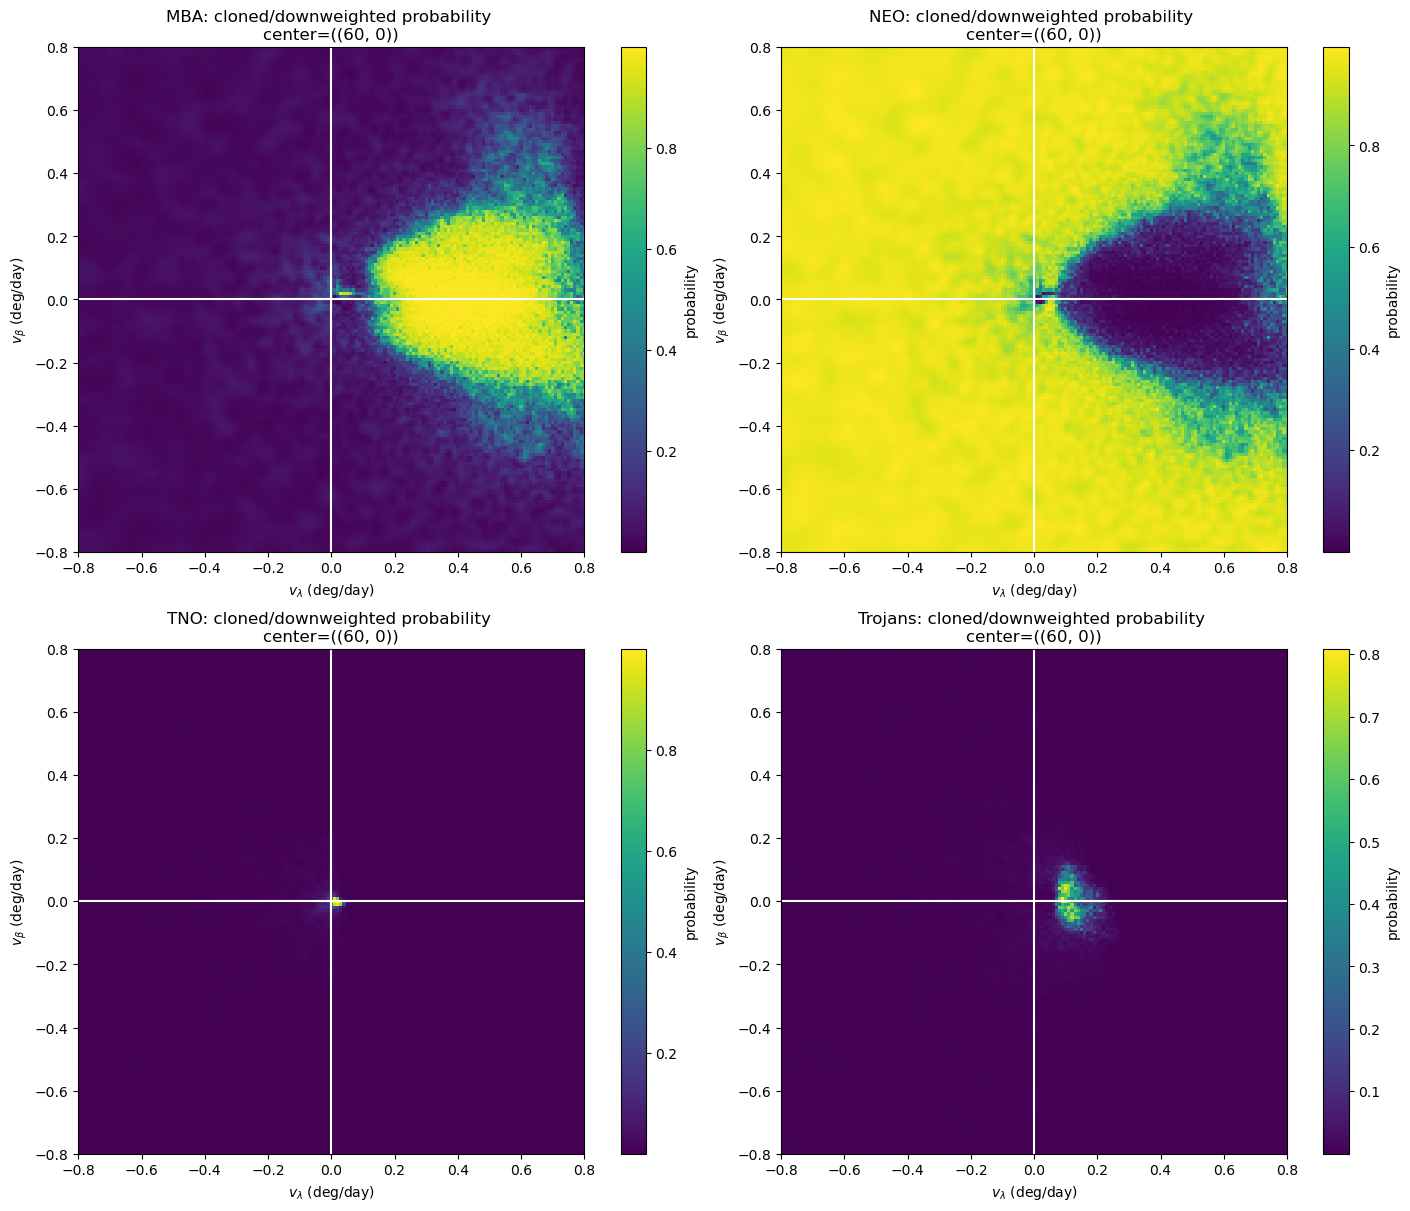

In [54]:
makeZIplots(result_lon60_lat00, 60, 0)

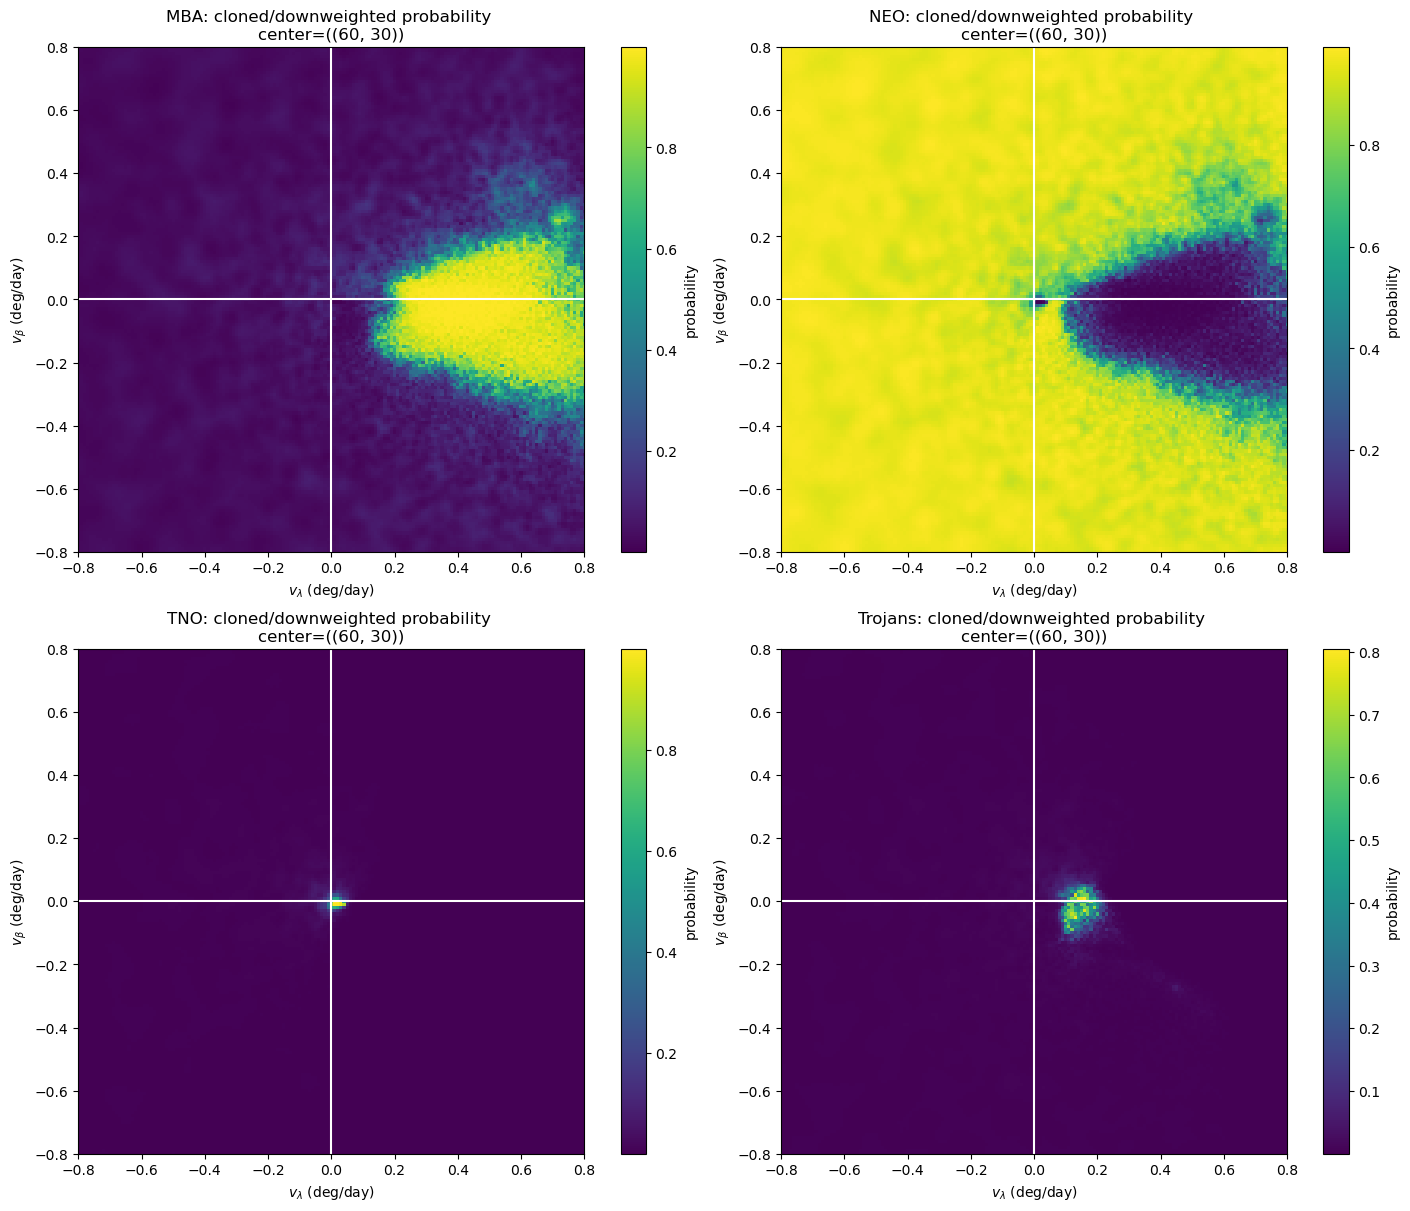

In [55]:
makeZIplots(result_lon60_lat30, 60, 30)